# All six models: combined plots, Λ = 300 MeV

Load saved **step50** results for Clausius–VDW/CS/TVM and Dieterici–VDW/CS/TVM, with $K_0=200,250,\ldots,750$ MeV. This notebook performs plotting only and can be used while the six calculation notebooks are still running. Run all cells again to refresh the figures from the latest checkpoints.

The six original figure groups and conventions are retained: model marker shapes, $K_0$ marker colors, solid/dashed asymmetric branches, and black VDW lines. Missing results are skipped; the coverage table identifies progress. Figures are saved as PDF, SVG, and PNG in `Paper/Clausius_Dieterici_3EV_Lambda300_K0_200_750_step50_combined/figures`.


In [1]:
from pathlib import Path
import json, os, tempfile
os.environ.setdefault('MPLBACKEND', 'Agg')
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'qmm_mpl_cache'))
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = next((p.resolve() for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/qmm').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Start Jupyter inside the QMM repository.')
K0_VALUES = list(range(200, 751, 50))
BRANCHES = ['target_l', 'equal_b']
Y_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5]
PAPER = ROOT / 'Paper/Clausius_Dieterici_3EV_Lambda300_K0_200_750_step50_combined'
FIGURES = PAPER / 'figures'
TABLES = PAPER / 'tables'
for directory in (FIGURES, TABLES):
    directory.mkdir(parents=True, exist_ok=True)
MODEL_SPECS = {
    'clausius_vdw': dict(label='Clausius–VDW', model_name='clausius', mean_field='clausius', ev='vdw', marker='o', bounds=(0.0, 6.2), template='guided_clausius_vdw_beta_lambda300_k0_300_target_l.json'),
    'clausius_cs':  dict(label='Clausius–CS',  model_name='clausius_cs', mean_field='clausius', ev='cs', marker='s', bounds=(-1.0, 6.1), template='guided_clausius_cs_beta_lambda300_highres_corrected_k0_300_target_l.json'),
    'clausius_tvm': dict(label='Clausius–TVM', model_name='clausius_tvm', mean_field='clausius', ev='tvm', marker='^', bounds=(-1.6, 6.1), template='guided_clausius_tvm_beta_lambda300_highres_corrected_k0_300_target_l.json'),
    'dieterici_vdw': dict(label='Dieterici–VDW', model_name='dieterici', mean_field='dieterici', ev='vdw', marker='D', bounds=(1.61, 2.01), template='guided_dieterici_vdw_beta_lambda300_highres_k0_300_target_l.json'),
    'dieterici_cs':  dict(label='Dieterici–CS',  model_name='dieterici_cs', mean_field='dieterici', ev='cs', marker='P', bounds=(1.64, 2.11), template='guided_dieterici_vdw_beta_lambda300_highres_k0_300_target_l.json'),
    'dieterici_tvm': dict(label='Dieterici–TVM', model_name='dieterici_tvm', mean_field='dieterici', ev='tvm', marker='X', bounds=(1.64, 2.16), template='guided_dieterici_vdw_beta_lambda300_highres_k0_300_target_l.json'),
}
for key, spec in MODEL_SPECS.items():
    spec['suite'] = f'guided_{key}_lambda300_k0_200_750_step50'
    spec['source_root'] = ROOT / 'results/generated' / spec['suite']
    spec['tov_dir'] = ROOT / 'results/generated' / f'{spec["suite"]}_tov'
    spec['tables'] = ROOT / f'Paper/{key}_Lambda300_K0_200_750_step50/tables'


## Load saved results and show coverage

In [2]:
# Read checkpoints directly, even if the model notebooks have not reached their final tables.
read_errors = []
def read_saved(path, kind):
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding='utf-8')) if kind == 'json' else pd.read_csv(path)
    except (ValueError, OSError, pd.errors.ParserError) as exc:
        read_errors.append({'path': str(path), 'error': str(exc)})
        return None

records, critical_rows, coverage = [], [], []
curve_index = {}
for key, spec in MODEL_SPECS.items():
    tov_rows = read_saved(spec['tov_dir'] / 'model_tov_summary.json', 'json') or []
    tov_lookup = {(int(r['K0_MeV']), r['branch_mode']): r for r in tov_rows}
    critical = read_saved(spec['tables'] / f'{key}_lambda300_fixed_y_critical_points.csv', 'csv')
    if critical is not None and not critical.empty:
        critical = critical[(critical.model_key == key) & critical.K0_MeV.isin(K0_VALUES)
                            & critical.branch_mode.isin(BRANCHES) & critical.y.round(8).isin(Y_VALUES)]
        critical_rows.extend(critical.to_dict('records'))
    counts = dict(model=spec['label'], beta=0, extended_eos=0, mass_radius=0,
                  expected_configurations=len(K0_VALUES)*len(BRANCHES))
    for k0 in K0_VALUES:
        for branch in BRANCHES:
            stem = f"{spec['suite']}_k0_{k0}_{branch}"
            directory = spec['source_root'] / f'K0_{k0}_{branch}'
            payload = read_saved(directory / f'{stem}_summary.json', 'json')
            beta = read_saved(directory / f'{stem}_asymmetric_beta.csv', 'csv')
            eos = read_saved(spec['tov_dir'] / 'extended_eos' / f'K0_{k0}_{branch}_extended_beta_eos.csv', 'csv')
            mr = read_saved(spec['tov_dir'] / 'curves' / f'K0_{k0}_{branch}_mass_radius.csv', 'csv')
            counts['beta'] += beta is not None
            counts['extended_eos'] += eos is not None
            counts['mass_radius'] += mr is not None
            if any(frame is not None for frame in (beta, eos, mr)):
                curve_index[(key,k0,branch)] = dict(beta=beta, eos=eos, mr=mr)
            if payload is None or 'asymmetric_fit' not in payload:
                continue
            fit = payload['asymmetric_fit']
            tov = tov_lookup.get((k0,branch), {})
            records.append(dict(model_key=key, model=spec['label'], K0_MeV=k0, branch_mode=branch,
                parameter_value=fit['parameter_value'], L_MeV=fit['L'], a_n=fit['a_n'], b_n=fit['b_n'],
                maximum_vs2_beta=float(beta.vs2.max()) if beta is not None else np.nan,
                maximum_mass_msun=tov.get('maximum_mass_msun', np.nan),
                radius_at_maximum_mass_km=tov.get('radius_at_maximum_mass_km', np.nan)))
    coverage.append(counts)
results = pd.DataFrame(records, columns=['model_key','model','K0_MeV','branch_mode',
    'parameter_value','L_MeV','a_n','b_n','maximum_vs2_beta','maximum_mass_msun','radius_at_maximum_mass_km'])
critical_df = pd.DataFrame(critical_rows, columns=['model_key','model','K0_MeV','branch_mode','y','status','nc_fm3','Tc_MeV','Pc_MeV_fm3'])
critical_df['y'] = pd.to_numeric(critical_df['y'])
results.to_csv(TABLES / 'six_models_lambda300_plot_results.csv', index=False)
critical_df.to_csv(TABLES / 'six_models_lambda300_fixed_y_critical_points.csv', index=False)
display(pd.DataFrame(coverage))
if read_errors:
    display(pd.DataFrame(read_errors))
print('Partial results are plotted as available. Rerun this cell and the plotting cells to refresh.')


,model,beta,extended_eos,mass_radius,expected_configurations
0,Clausius–VDW,24,24,24,24
1,Clausius–CS,24,24,24,24
2,Clausius–TVM,24,24,15,24
3,Dieterici–VDW,24,24,24,24
4,Dieterici–CS,24,24,24,24
5,Dieterici–TVM,24,24,15,24


Partial results are plotted as available. Rerun this cell and the plotting cells to refresh.


In [3]:
mpl.rcParams.update({
    'font.family':'serif', 'font.serif':['STIXGeneral','DejaVu Serif'],
    'mathtext.fontset':'stix', 'font.size':8.5, 'axes.labelsize':9.5,
    'axes.linewidth':.8, 'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.top':True, 'ytick.right':True, 'legend.frameon':False,
    'pdf.fonttype':42, 'ps.fonttype':42, 'savefig.bbox':'tight',
})
CMAP = mpl.colormaps['turbo']; NORM = mpl.colors.Normalize(200, 750)
BRANCH_STYLE = {'target_l':'-', 'equal_b':'--'}
BRANCH_LABEL = {'target_l':r'$b_{pn}\ne b_n$', 'equal_b':r'$b_{pn}=b_n$'}

def kcolor(k0): return CMAP(NORM(k0))
def line_color(spec, k0): return 'black' if spec['ev'] == 'vdw' else kcolor(k0)
def curve_style(spec, k0, branch, markevery=14):
    return dict(color=line_color(spec,k0), ls=BRANCH_STYLE[branch], lw=.65,
                marker=spec['marker'], markevery=markevery, ms=2.0,
                mfc=kcolor(k0), mec='black' if spec['ev']=='vdw' else kcolor(k0), mew=.25, alpha=.72)

def add_legends(fig, axis):
    model_handles = [mpl.lines.Line2D([],[], color='black' if s['ev']=='vdw' else '.45', marker=s['marker'],
                    mfc='white', mec='black', lw=.8, label=s['label']) for s in MODEL_SPECS.values()]
    branch_handles = [mpl.lines.Line2D([],[], color='black', ls=BRANCH_STYLE[b], label=BRANCH_LABEL[b]) for b in BRANCHES]
    first = axis.legend(handles=model_handles, fontsize=6.7, ncol=2, loc='best')
    axis.add_artist(first); axis.legend(handles=branch_handles, fontsize=7, loc='lower right')
    sm = mpl.cm.ScalarMappable(norm=NORM, cmap=CMAP); sm.set_array([])
    fig.colorbar(sm, ax=fig.axes, fraction=.018, pad=.015, label=r'$K_0$ [MeV]')

def finish(fig, name):
    for ax in fig.axes:
        if hasattr(ax, 'grid'): ax.grid(color='.92', lw=.4)
    fig.suptitle('Clausius and Dieterici: VDW / CS / TVM, Λ = 300 MeV'
                 + (' — partial results' if sum(c['beta'] for c in coverage) < 144 or len(critical_df) < 720 or sum(c['mass_radius'] for c in coverage) < 144 else ''), fontsize=11)
    fig.savefig(FIGURES / f'{name}.pdf')
    fig.savefig(FIGURES / f'{name}.svg')
    fig.savefig(FIGURES / f'{name}.png', dpi=260)
    plt.close(fig)



In [4]:
# (1) beta binding and sound speed, one row per branch.
fig, axes = plt.subplots(2,2,figsize=(10.5,7.0))
for row_i, branch in enumerate(BRANCHES):
    for (key,k0,b), curves in curve_index.items():
        if b != branch: continue
        spec=MODEL_SPECS[key]; beta=curves['beta']
        if beta is None: continue
        binding=((beta.energy_density-beta.eps_e-beta.eps_mu)/beta.n_b-938.0)/1000
        axes[row_i,0].plot(beta.n_over_n0,binding,**curve_style(spec,k0,branch))
        axes[row_i,1].plot(beta.n_over_n0,beta.vs2,**curve_style(spec,k0,branch))
    axes[row_i,0].set(xlim=(0,5),xlabel=r'$n_B/n_0$',ylabel=r'$\epsilon_{HQ}/n_B-m_N$ [GeV]')
    axes[row_i,1].set(xlim=(0,5),xlabel=r'$n_B/n_0$',ylabel=r'$c_s^2$')
    axes[row_i,1].text(.98,.96,BRANCH_LABEL[branch],transform=axes[row_i,1].transAxes,ha='right',va='top')
add_legends(fig,axes[0,0]); finish(fig,'figure_six_models_beta_binding_sound')



In [5]:
# (2) beta composition.
fig, axes = plt.subplots(2,2,figsize=(10.5,7.0))
for row_i, branch in enumerate(BRANCHES):
    for (key,k0,b), curves in curve_index.items():
        if b != branch: continue
        spec=MODEL_SPECS[key]; beta=curves['beta']
        if beta is None: continue
        axes[row_i,0].plot(beta.n_over_n0,beta.y,**curve_style(spec,k0,branch))
        axes[row_i,1].plot(beta.n_over_n0,beta.quark_fraction,**curve_style(spec,k0,branch))
    axes[row_i,0].set(xlim=(0,5),ylim=(0,.5),xlabel=r'$n_B/n_0$',ylabel=r'$y$')
    axes[row_i,1].set(xlim=(0,5),ylim=(0,1),xlabel=r'$n_B/n_0$',ylabel=r'$f_q$')
    axes[row_i,1].text(.98,.96,BRANCH_LABEL[branch],transform=axes[row_i,1].transAxes,ha='right',va='top')
add_legends(fig,axes[0,0]); finish(fig,'figure_six_models_beta_composition')



In [6]:
# (3) extended EoS and mass-radius curves.
fig, axes = plt.subplots(2,2,figsize=(10.5,7.0))
for row_i, branch in enumerate(BRANCHES):
    for (key,k0,b), curves in curve_index.items():
        if b != branch: continue
        spec=MODEL_SPECS[key]; eos=curves['eos']; mr=curves['mr']
        if eos is not None: axes[row_i,0].plot(eos.energy_density/1000,eos.pressure/1000,**curve_style(spec,k0,branch))
        if mr is not None: axes[row_i,1].plot(mr.radius_km,mr.mass_msun,**curve_style(spec,k0,branch,markevery=25))
    axes[row_i,0].set(xlabel=r'$\epsilon$ [GeV fm$^{-3}$]',ylabel=r'$p$ [GeV fm$^{-3}$]')
    axes[row_i,1].set(xlabel=r'$R$ [km]',ylabel=r'$M$ [$M_\odot$]')
    axes[row_i,1].text(.98,.96,BRANCH_LABEL[branch],transform=axes[row_i,1].transAxes,ha='right',va='top')
add_legends(fig,axes[0,0]); finish(fig,'figure_six_models_eos_mass_radius')



In [7]:
# (4) maximum observables.
fig, axes = plt.subplots(1,3,figsize=(12.2,3.9),sharex=True)
fields=[('maximum_mass_msun',r'$M_{\max}$ [$M_\odot$]'),('radius_at_maximum_mass_km',r'$R_{M_{\max}}$ [km]'),('maximum_vs2_beta',r'$\max c_s^2$')]
for ax,(field,ylabel) in zip(axes,fields):
    for key,spec in MODEL_SPECS.items():
        for branch in BRANCHES:
            part=results[(results.model_key==key)&(results.branch_mode==branch)].sort_values('K0_MeV')
            ax.plot(part.K0_MeV,part[field],**curve_style(spec,part.K0_MeV.iloc[0] if len(part) else 200,branch,markevery=1))
            if len(part):
                ax.scatter(part.K0_MeV,part[field],c=part.K0_MeV,cmap=CMAP,norm=NORM,marker=spec['marker'],s=13,
                           edgecolors='black' if spec['ev']=='vdw' else 'none',linewidths=.25,zorder=3)
    ax.set(xlabel=r'$K_0$ [MeV]',ylabel=ylabel)
add_legends(fig,axes[0]); finish(fig,'figure_six_models_observables')



In [8]:
# (5) fitted parameters.
fig, axes = plt.subplots(2,2,figsize=(10.2,7.0),sharex=True)
panels=[('parameter_value','model parameter'),('L_MeV',r'$L$ [MeV]'),('a_n',r'$a_n$ [MeV fm$^3$]'),('b_n',r'$b_n$ [fm$^3$]')]
for ax,(field,ylabel) in zip(axes.flat,panels):
    for key,spec in MODEL_SPECS.items():
        for branch in BRANCHES:
            part=results[(results.model_key==key)&(results.branch_mode==branch)].sort_values('K0_MeV')
            if not len(part): continue
            ax.plot(part.K0_MeV,part[field],color='black' if spec['ev']=='vdw' else '.55',ls=BRANCH_STYLE[branch],lw=.7)
            ax.scatter(part.K0_MeV,part[field],c=part.K0_MeV,cmap=CMAP,norm=NORM,marker=spec['marker'],s=12,
                       edgecolors='black' if spec['ev']=='vdw' else 'none',linewidths=.25)
    ax.set(ylabel=ylabel)
for ax in axes[-1]: ax.set_xlabel(r'$K_0$ [MeV]')
add_legends(fig,axes[0,0]); finish(fig,'figure_six_models_fitted_parameters')



In [9]:
# (6) fixed-y critical points: five rows, all models together.
fig, axes = plt.subplots(len(Y_VALUES),2,figsize=(11.0,15.0),sharex=True)
okcrit = critical_df[critical_df.status=='ok'] if not critical_df.empty else critical_df
for row_i,y in enumerate(Y_VALUES):
    for key,spec in MODEL_SPECS.items():
        for branch in BRANCHES:
            part=okcrit[(okcrit.model_key==key)&(okcrit.branch_mode==branch)&np.isclose(okcrit.y,y)].sort_values('K0_MeV')
            if not len(part): continue
            for ax,field in zip(axes[row_i],['nc_fm3','Tc_MeV']):
                ax.plot(part.K0_MeV,part[field],color='black' if spec['ev']=='vdw' else '.55',ls=BRANCH_STYLE[branch],lw=.65)
                ax.scatter(part.K0_MeV,part[field],c=part.K0_MeV,cmap=CMAP,norm=NORM,marker=spec['marker'],s=11,
                           edgecolors='black' if spec['ev']=='vdw' else 'none',linewidths=.25)
    axes[row_i,0].set_ylabel(rf'$n_c$ [fm$^{{-3}}$], $y={y:.1f}$')
    axes[row_i,1].set_ylabel(rf'$T_c$ [MeV], $y={y:.1f}$')
for ax in axes[-1]: ax.set_xlabel(r'$K_0$ [MeV]')
add_legends(fig,axes[0,0]); finish(fig,'figure_six_models_fixed_y_critical')

print('Saved six combined figures in PDF, SVG, and PNG under', FIGURES)

Saved six combined figures in PDF, SVG, and PNG under /home/dajuarez4/QMM/Paper/Clausius_Dieterici_3EV_Lambda300_K0_200_750_step50_combined/figures


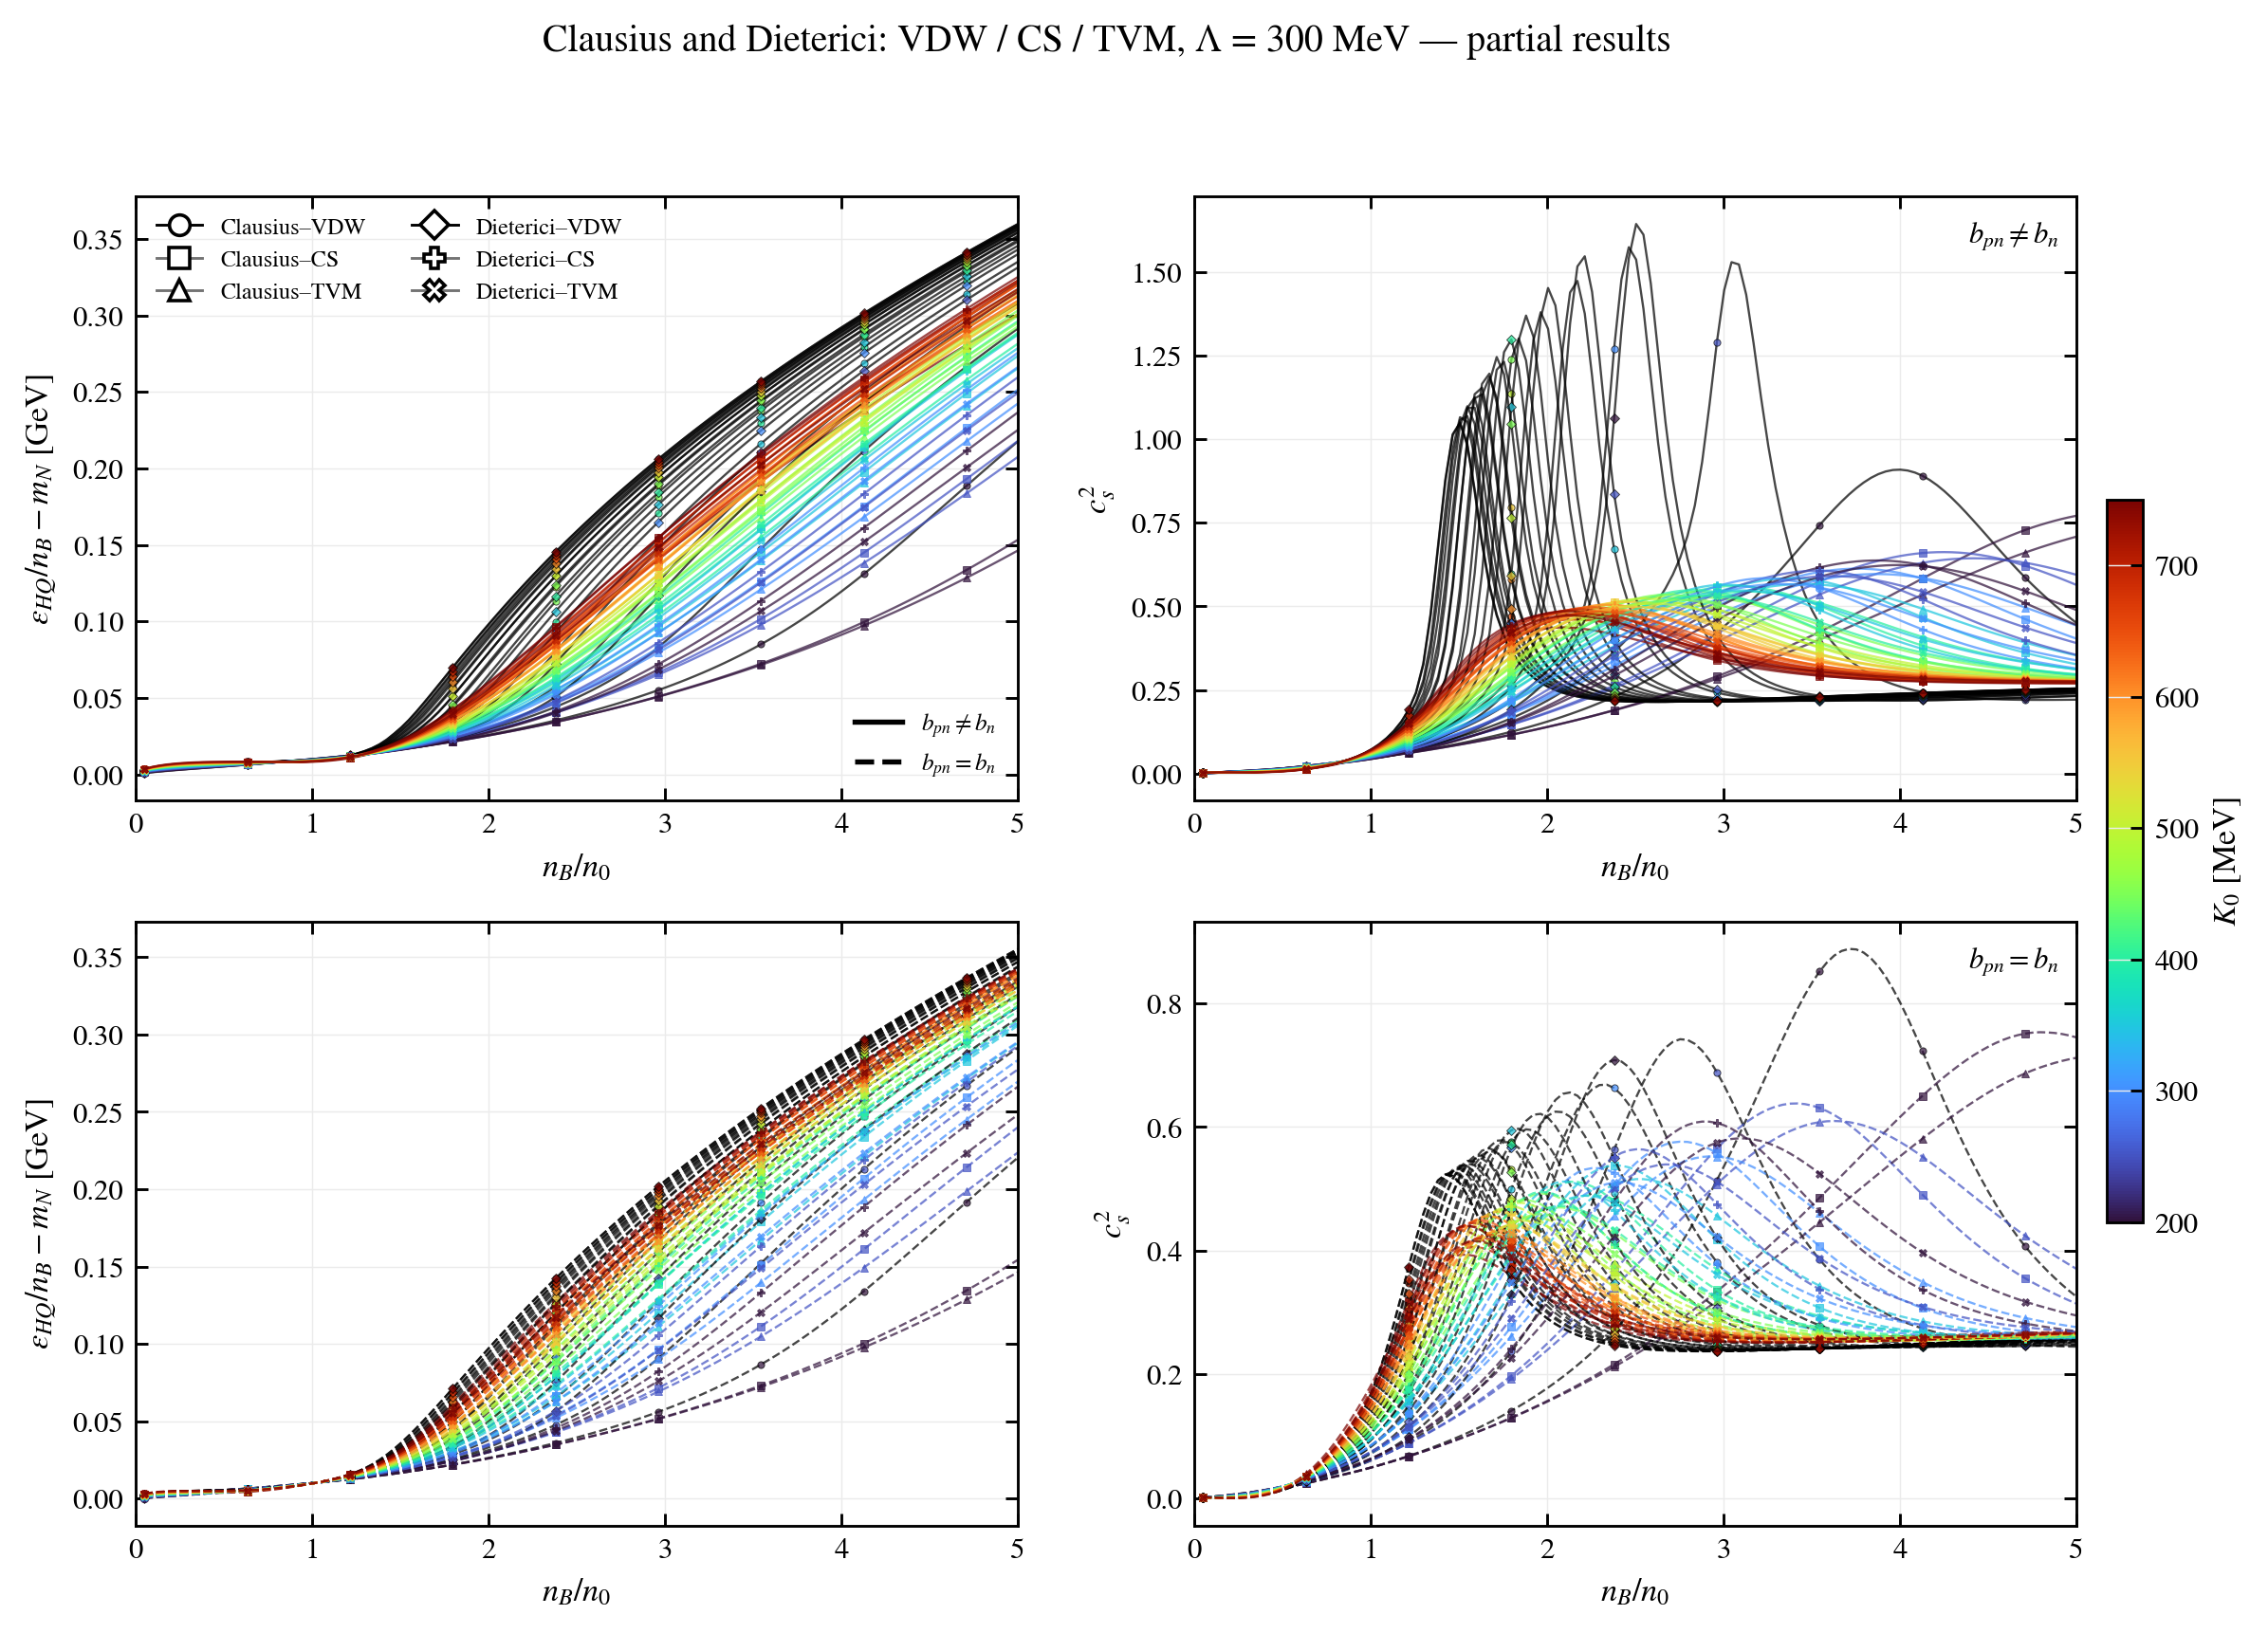

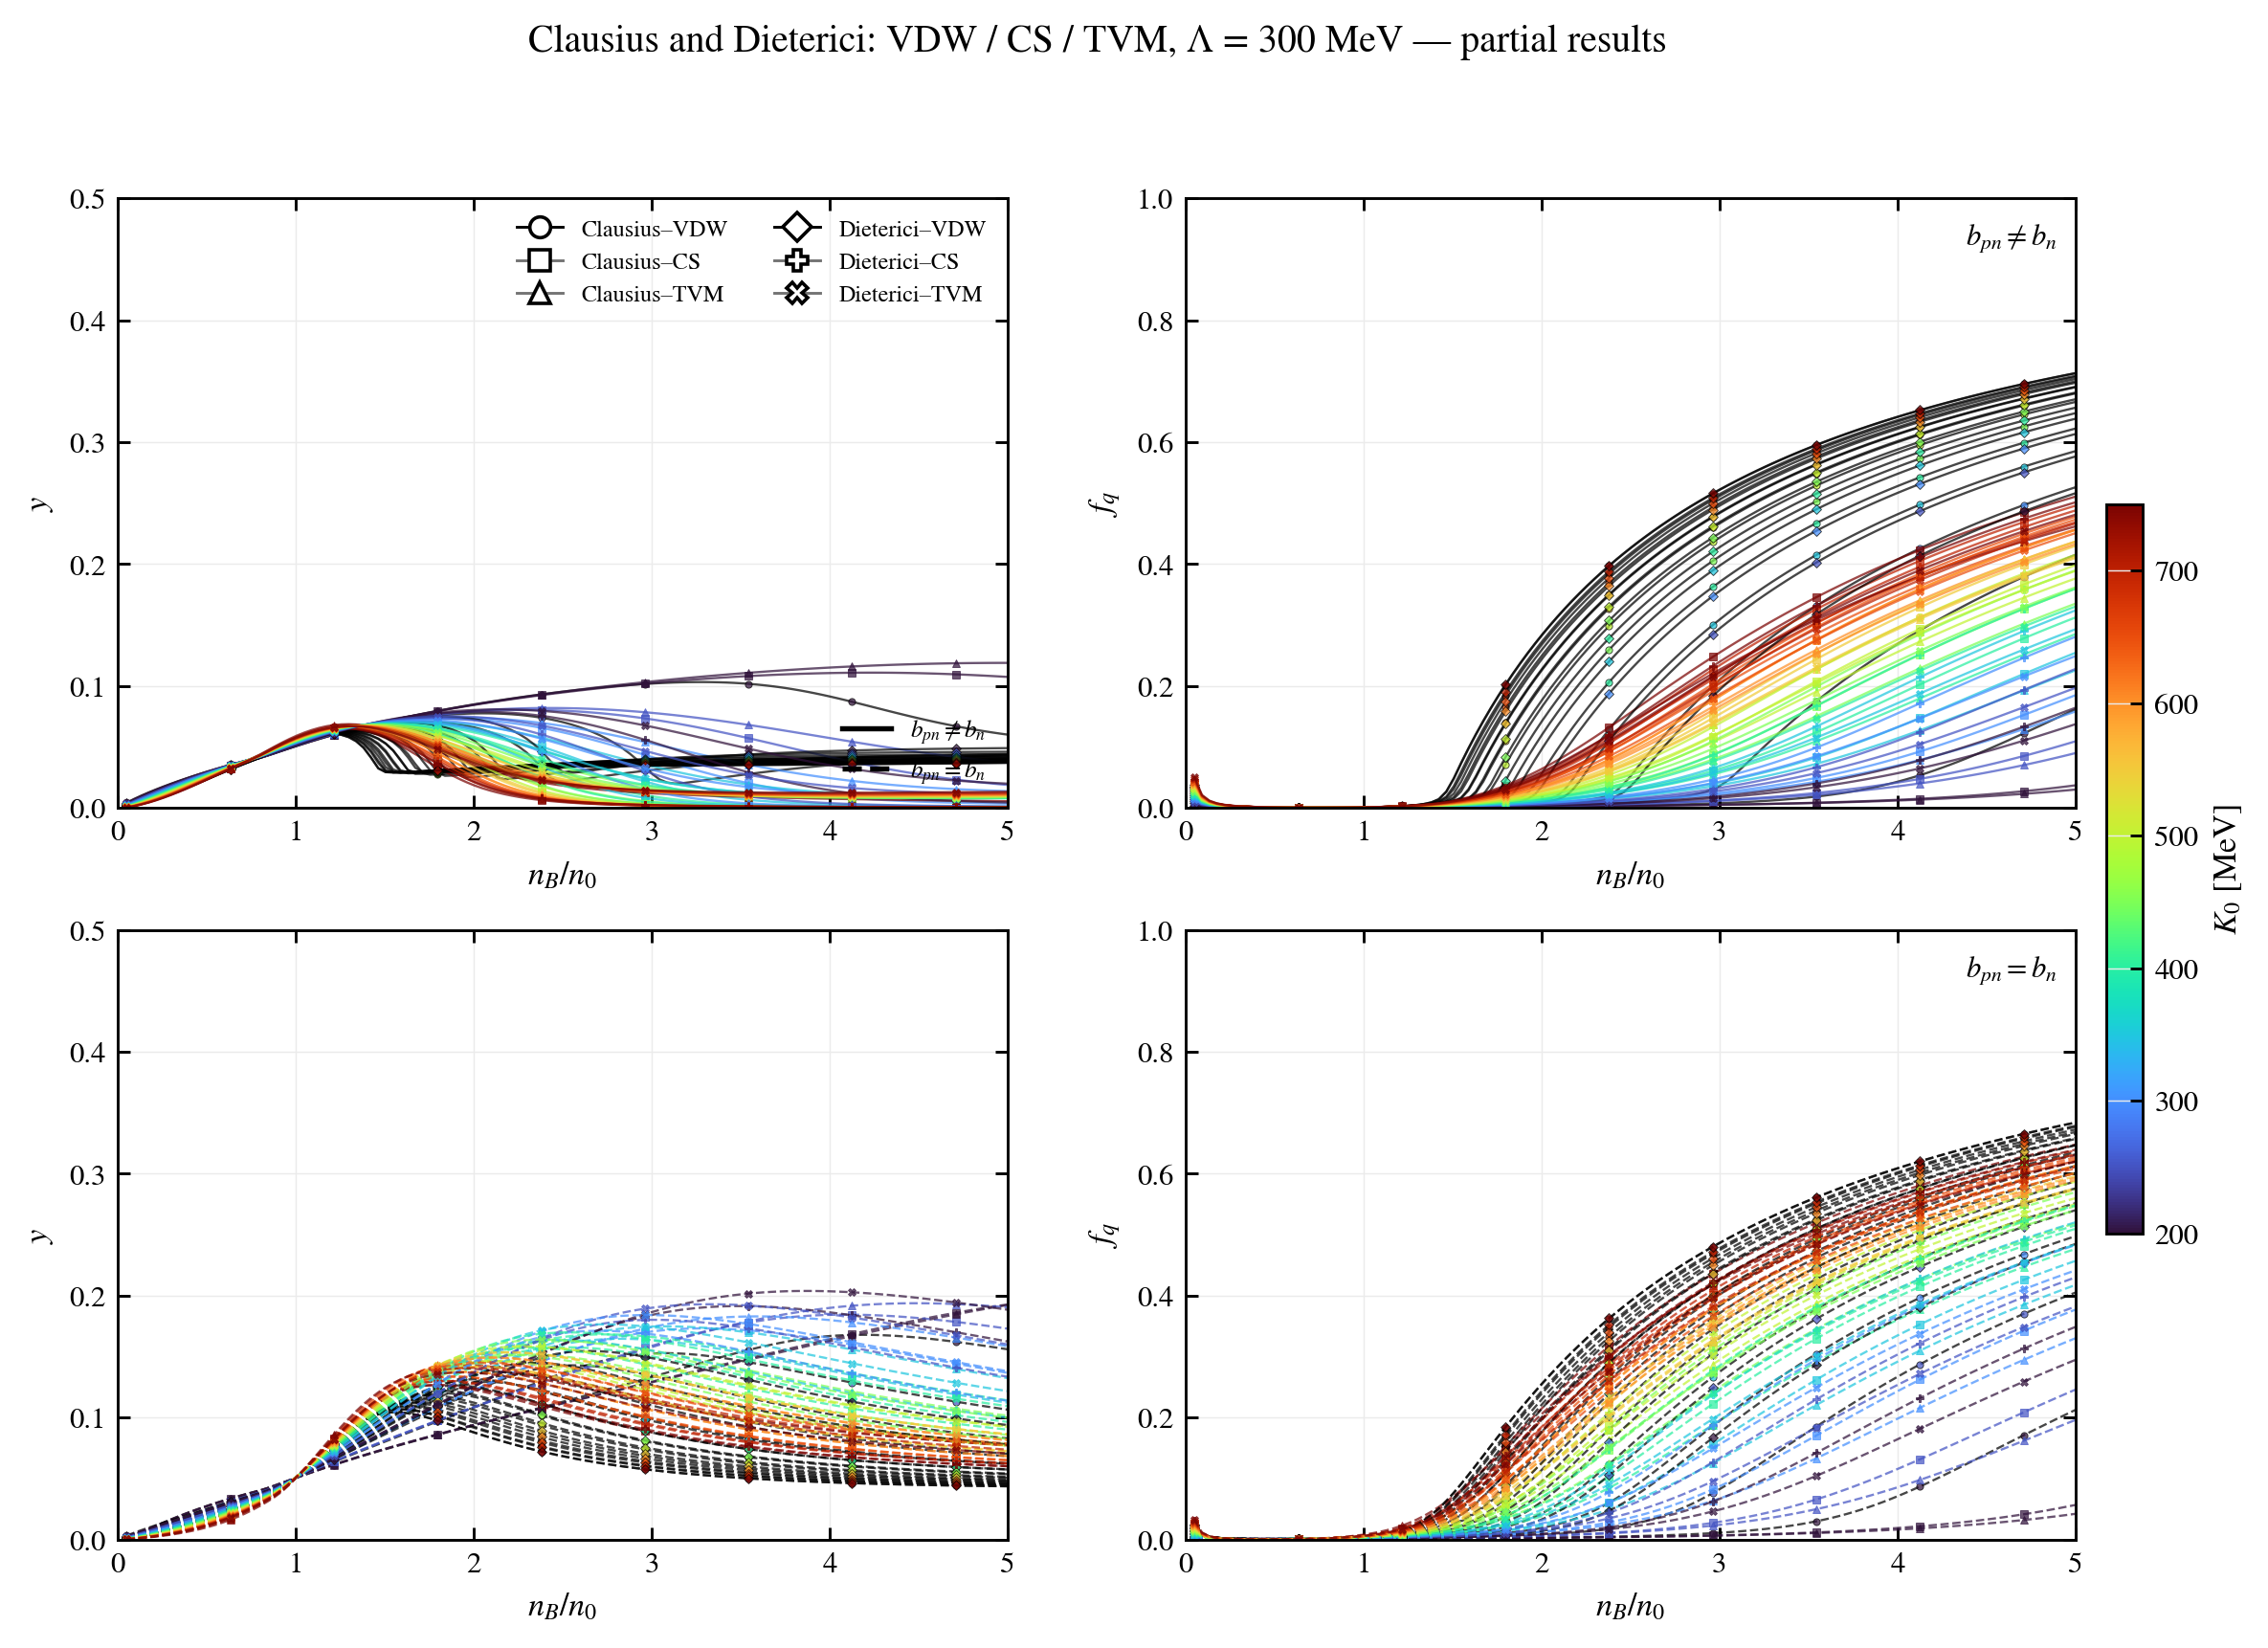

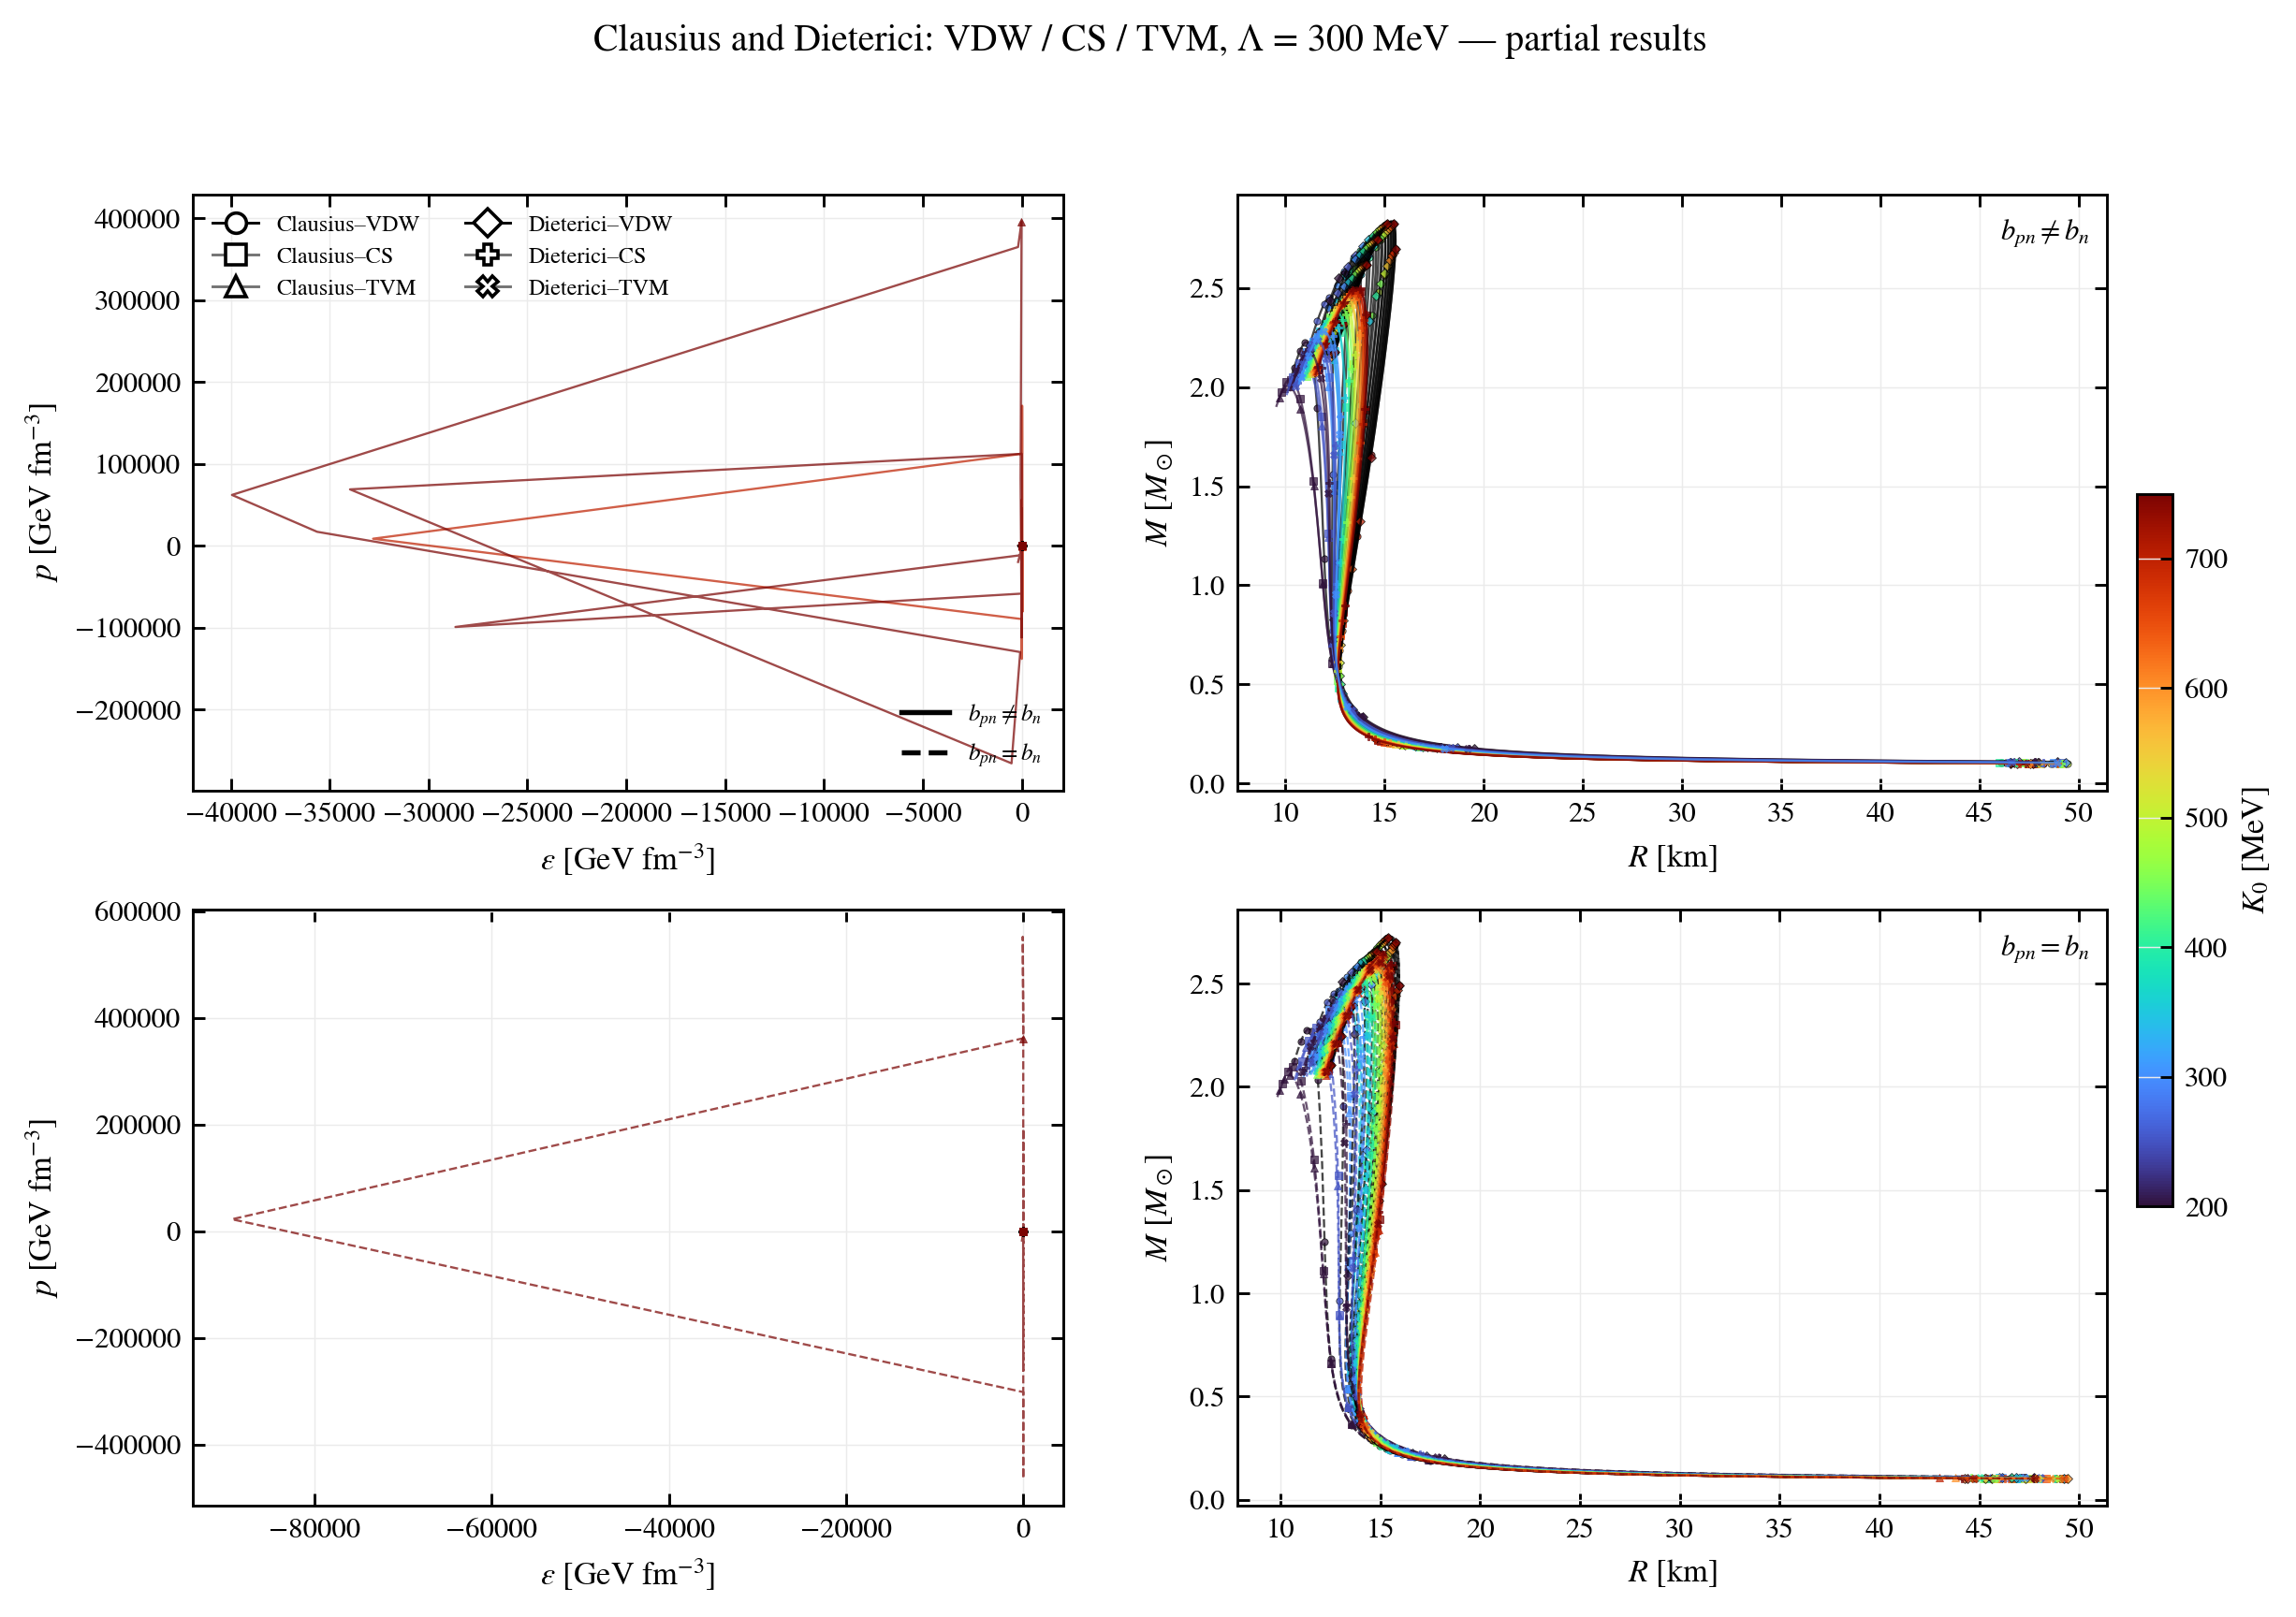

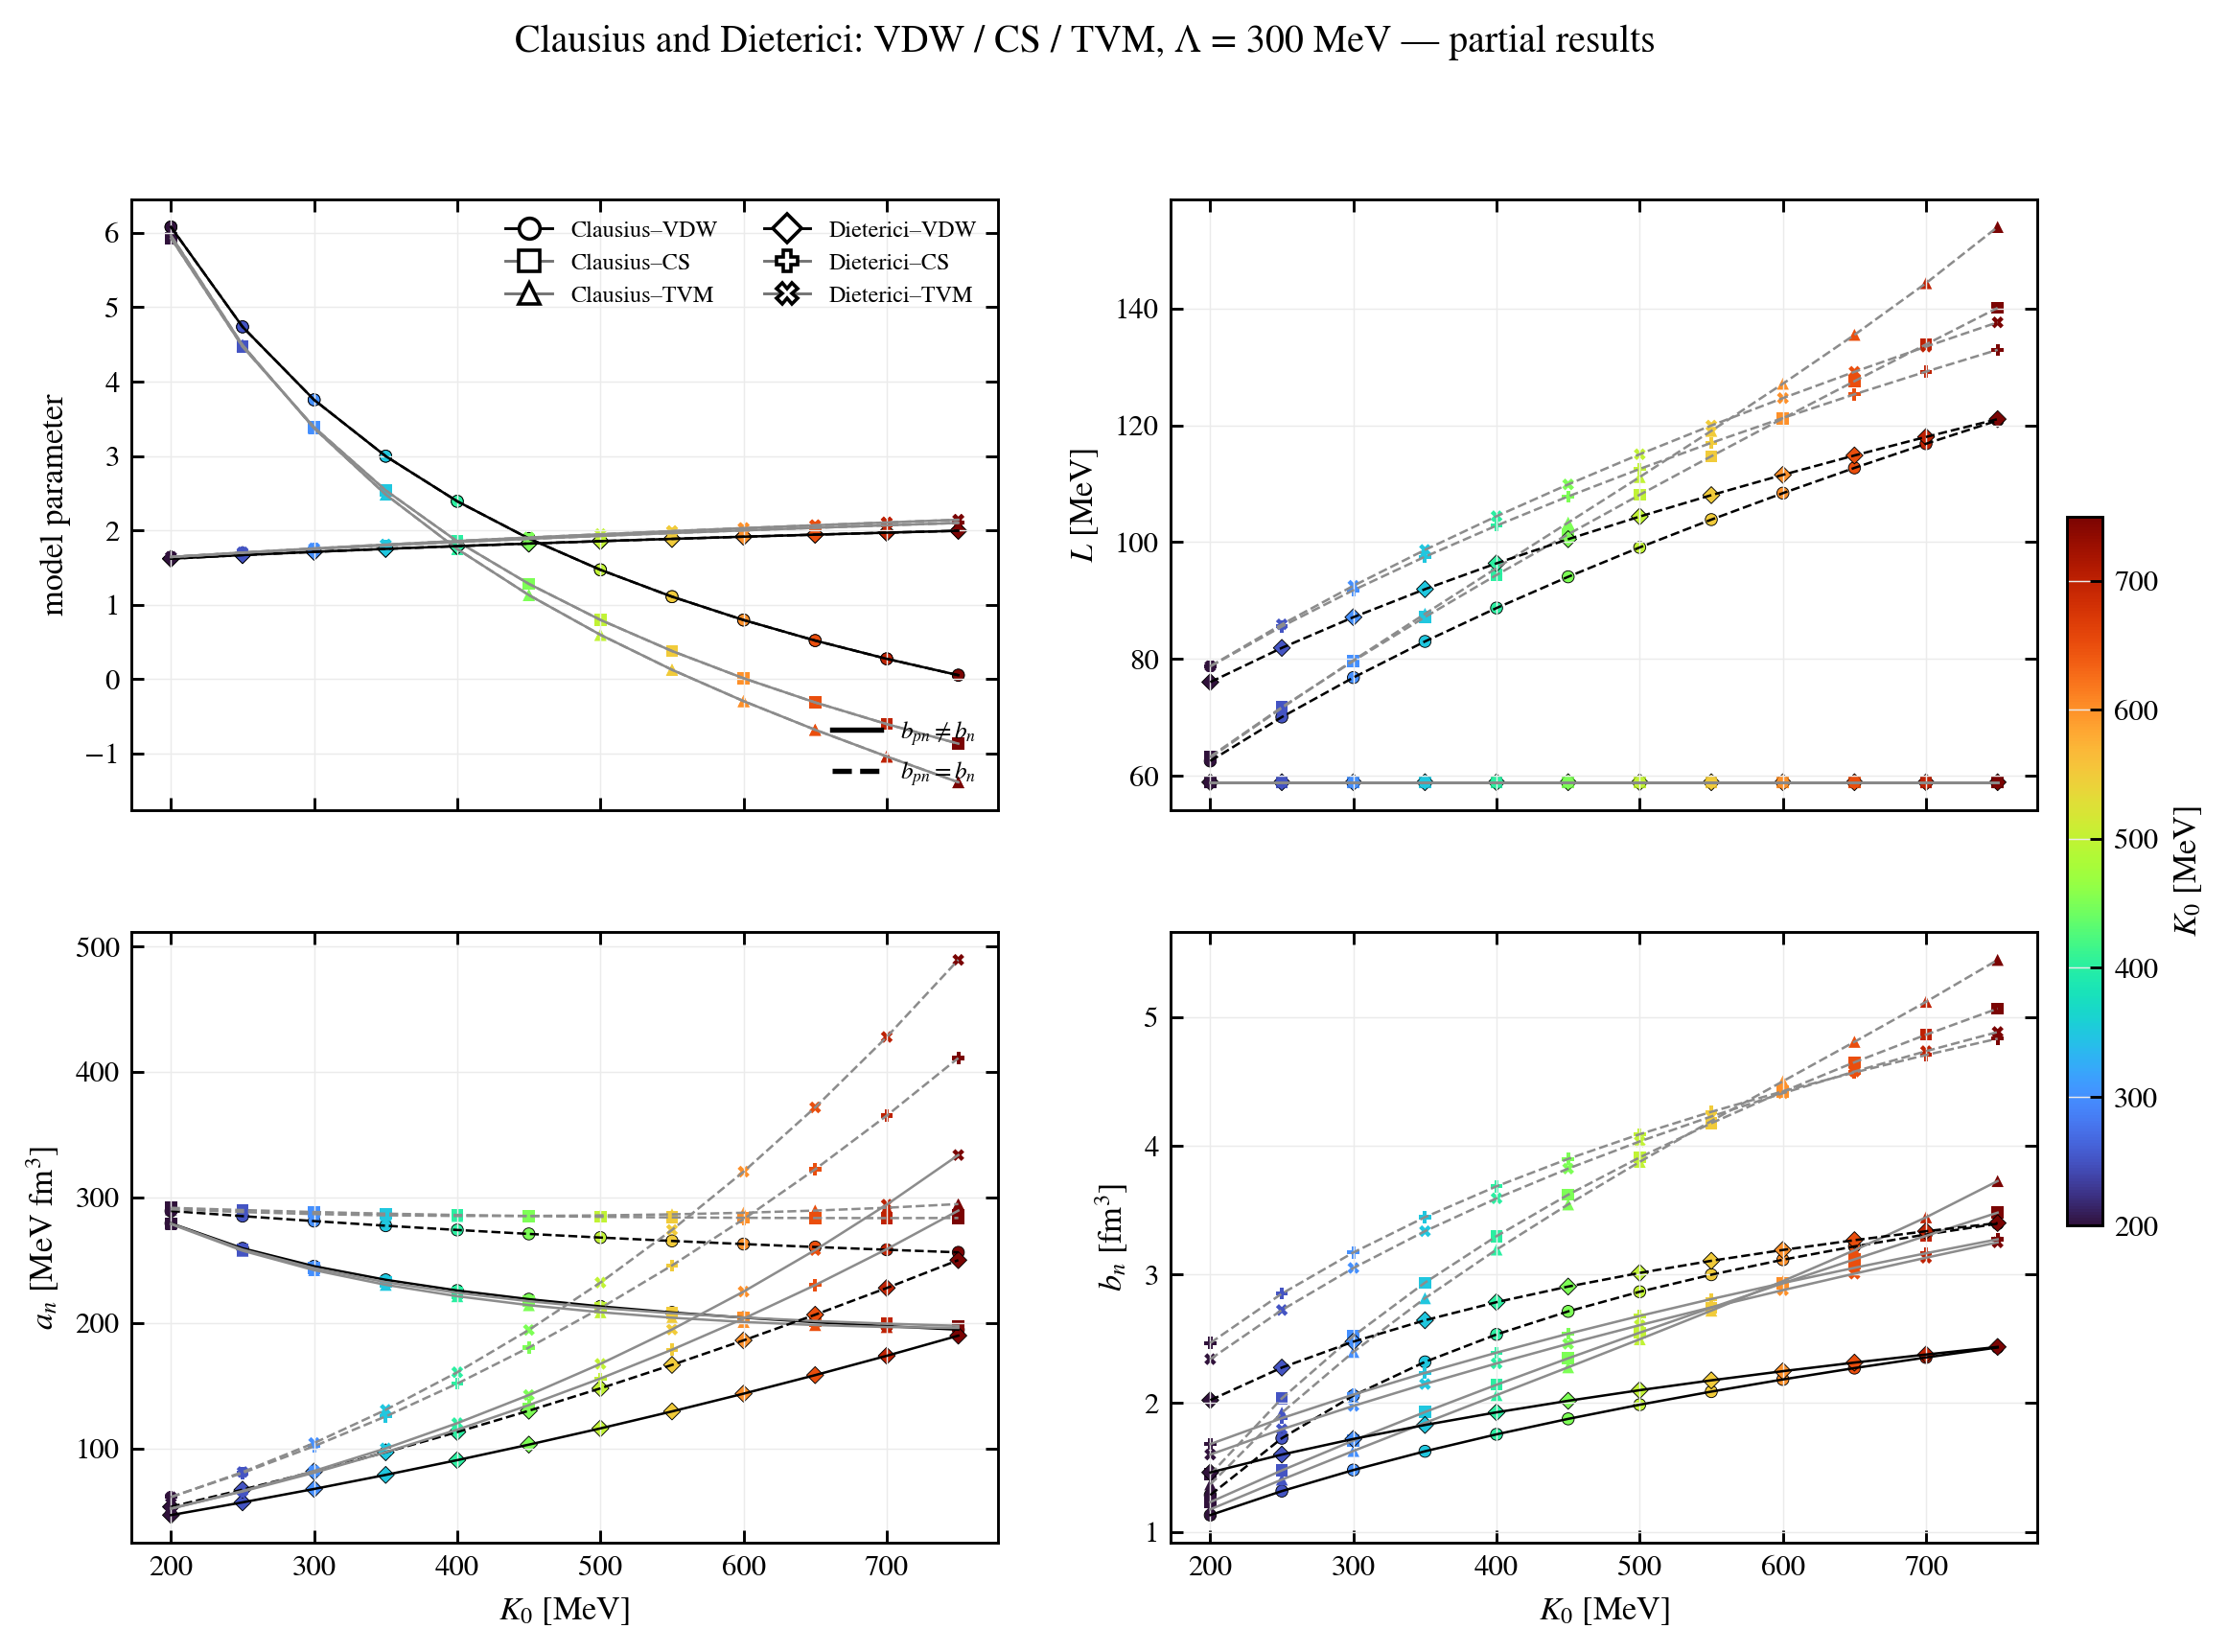

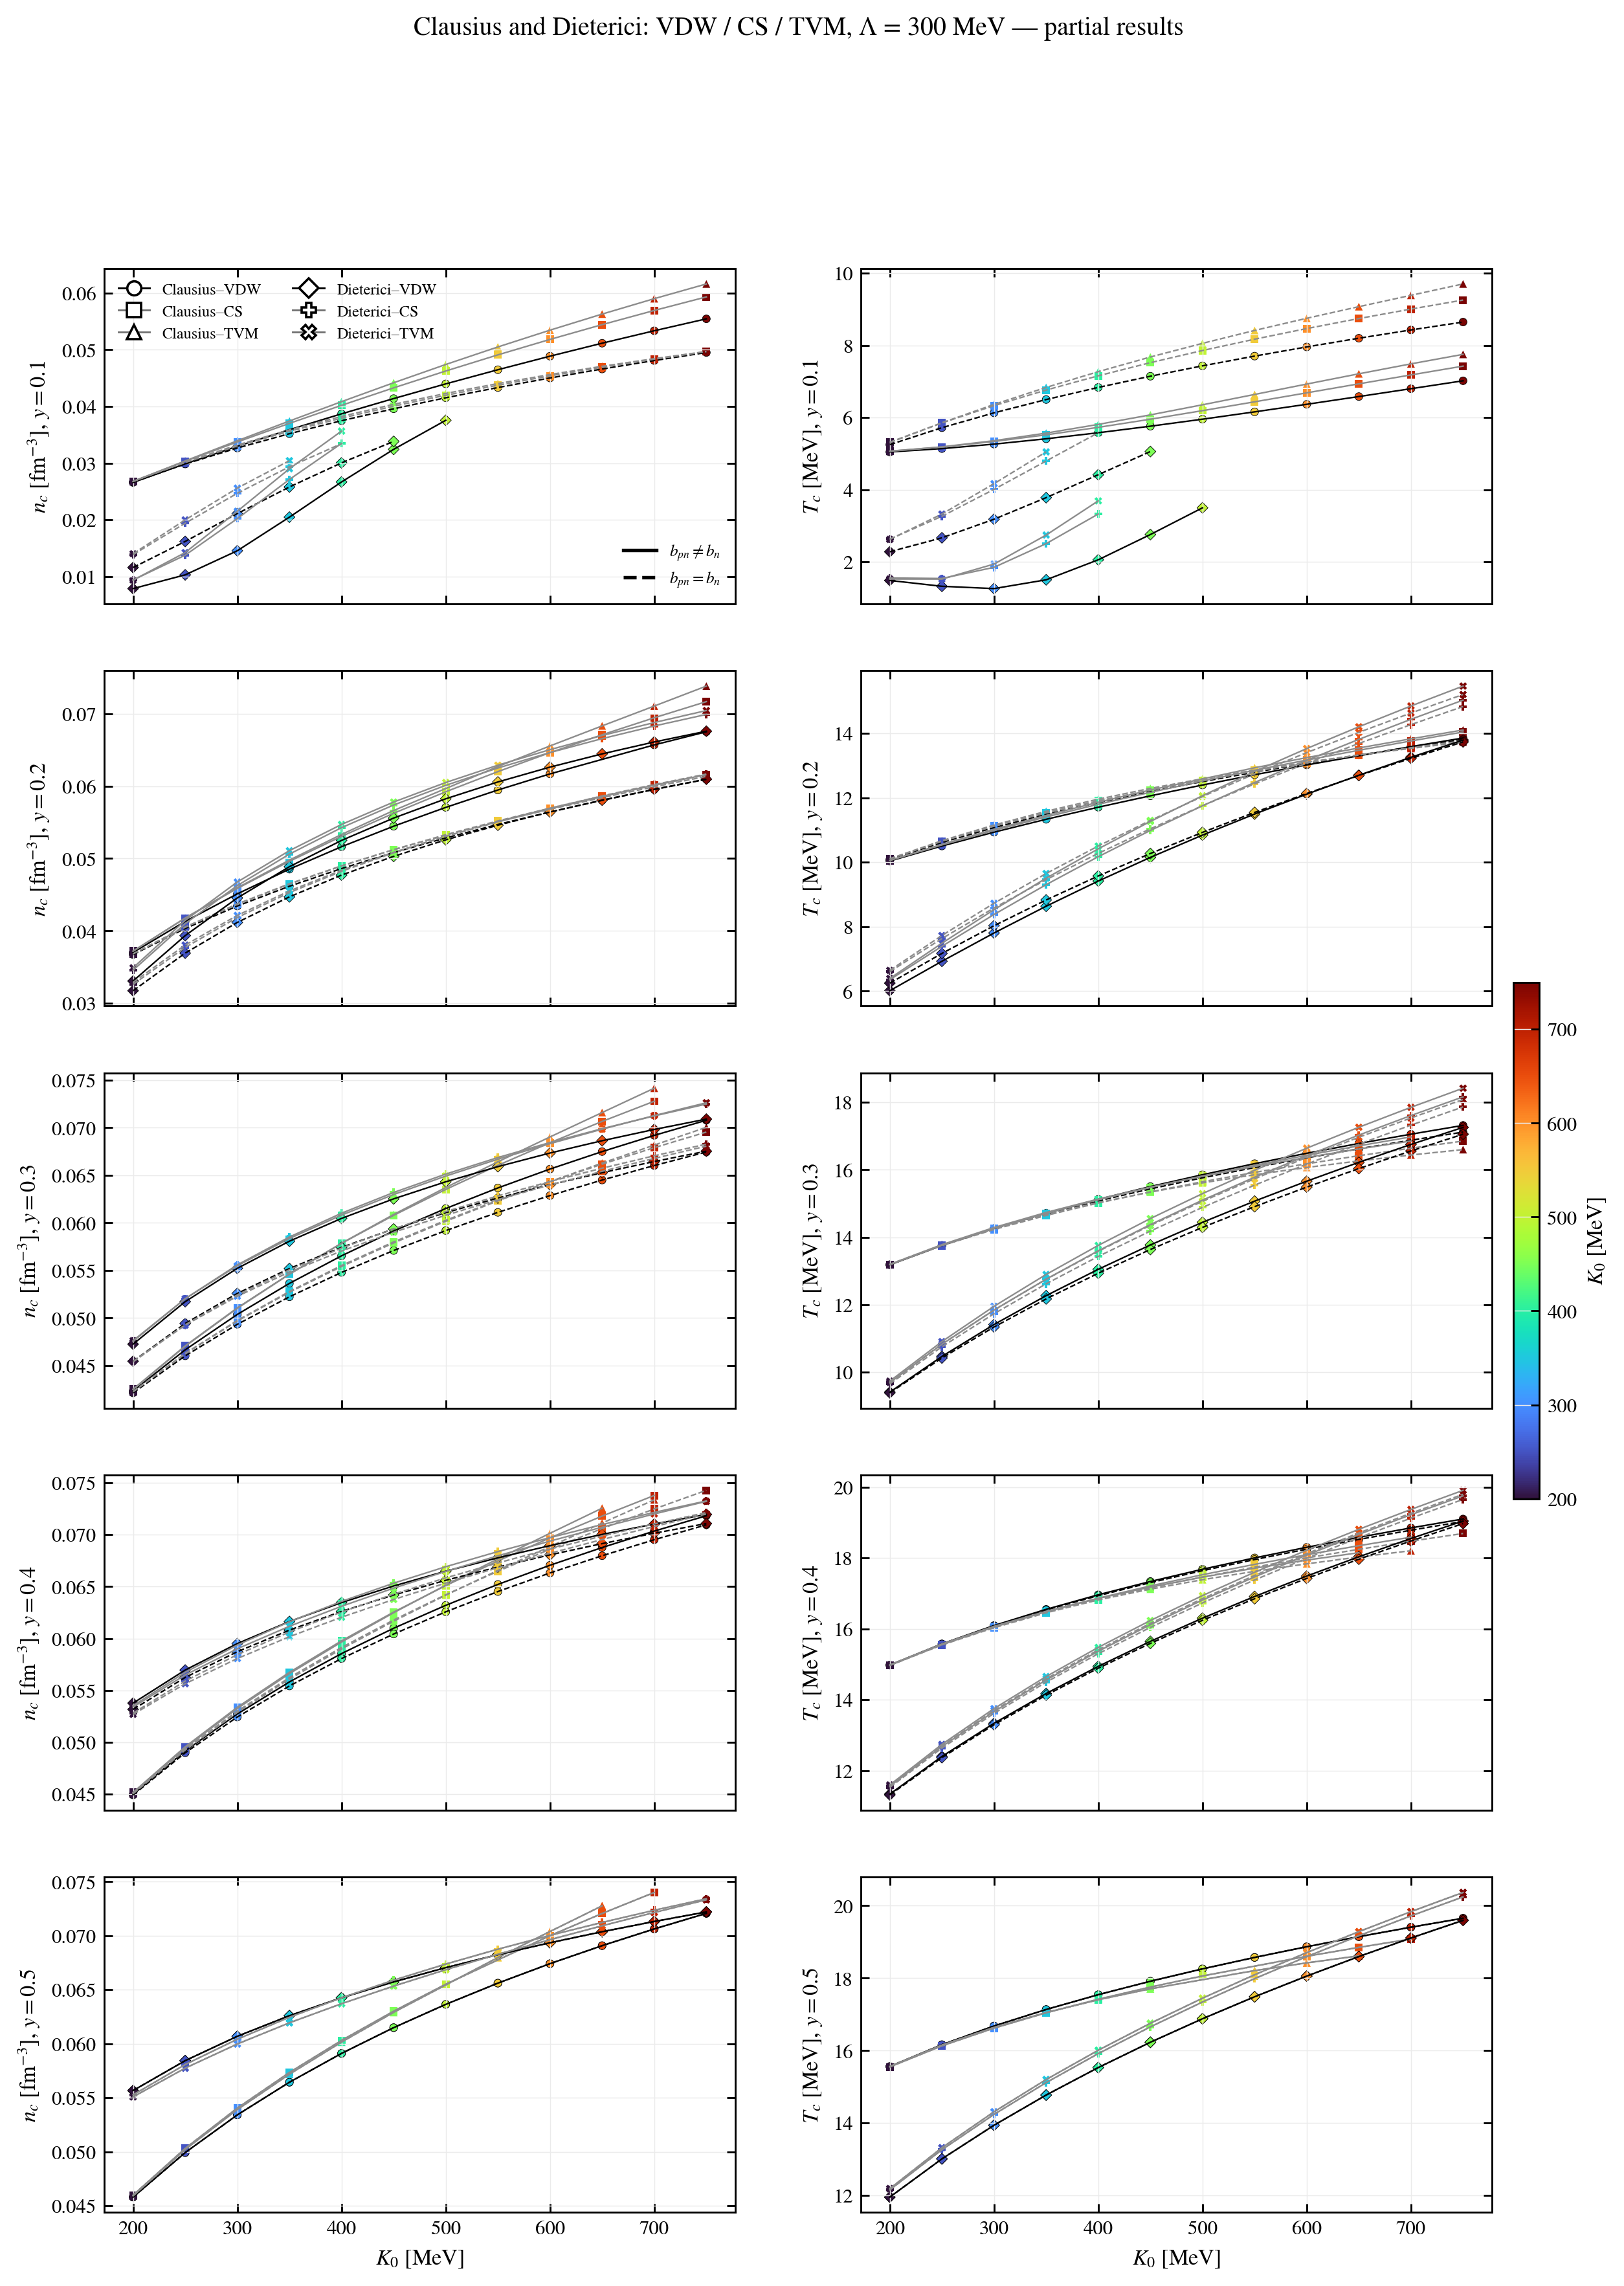

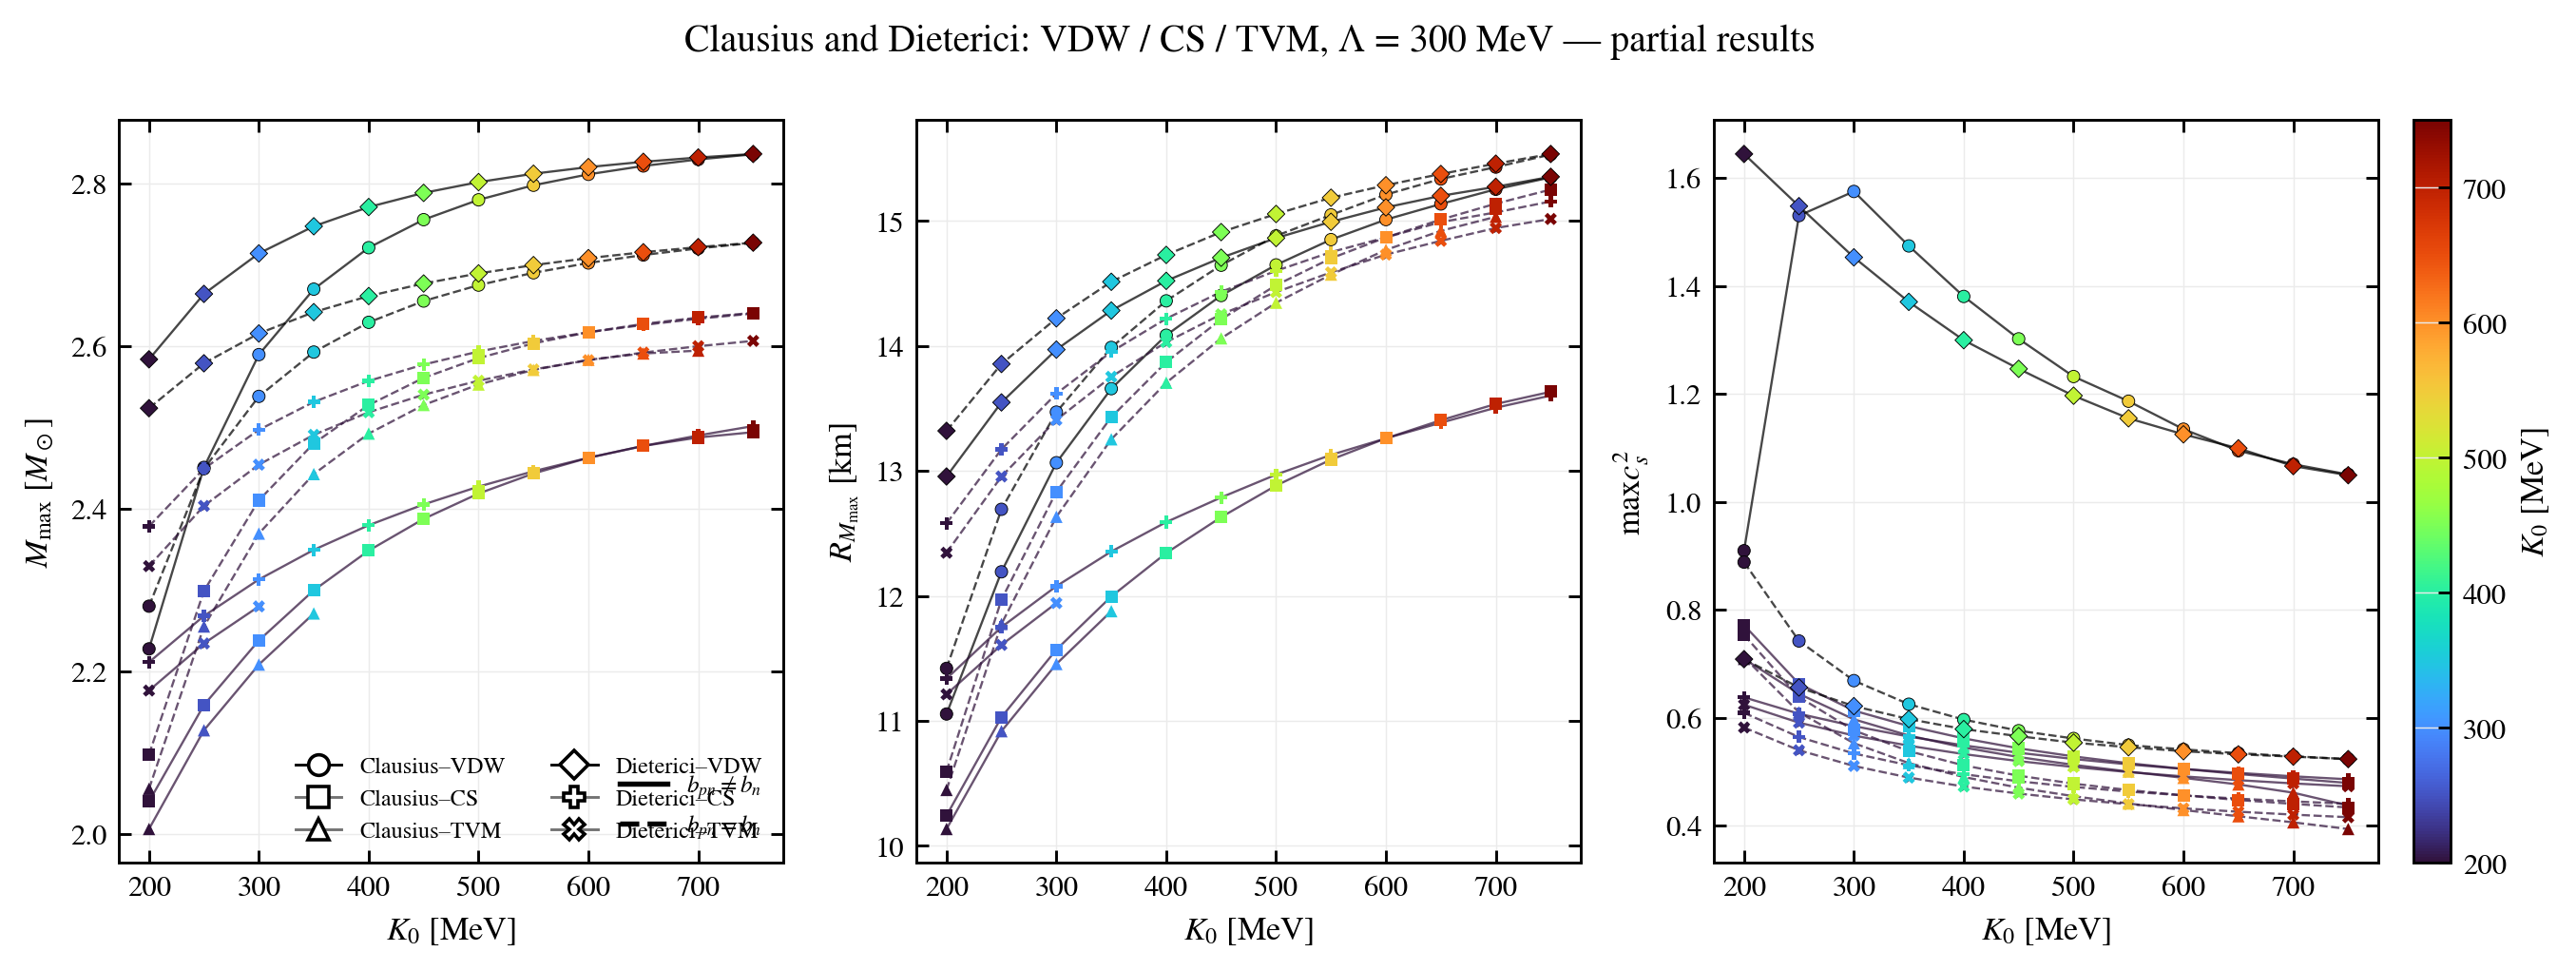

Figures: /home/dajuarez4/QMM/Paper/Clausius_Dieterici_3EV_Lambda300_K0_200_750_step50_combined/figures


In [10]:
for path in sorted(FIGURES.glob('figure_six_models_*.png')):
    display(Image(filename=str(path)))
print('Figures:', FIGURES)